In [2]:
# =========================================================
# CELL 1 : IMPORT LIBRARIES
# =========================================================

import os
import cv2
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from skimage.feature import hog
from skimage.feature import local_binary_pattern

In [3]:
# =========================================================
# CELL 2 : SETTINGS
# =========================================================

IMG_SIZE = 128



In [4]:
# =========================================================
# CELL : EXTRACT ZIP DATASET
# =========================================================

# ZIP file path
ZIP_FILE = "archive.zip"

# Folder where dataset will be extracted
DATASET_FOLDER = "dataset"

# Create folder
os.makedirs(DATASET_FOLDER, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(DATASET_FOLDER)

print("ZIP Extracted Successfully")



ZIP Extracted Successfully


In [6]:
# Dataset path for further use
dataset_path ="dataset/data"

print("Dataset Path :", dataset_path)
# =========================================================
# PRINT CLASSES NAME
# =========================================================

classes = os.listdir(dataset_path)

print("\nClasses Found :")

for class_name in classes:
    print(class_name)

Dataset Path : dataset/data

Classes Found :
with_mask
without_mask


In [20]:
# =========================================================
# CELL 4 : PREPROCESS IMAGE FUNCTION
# =========================================================

def preprocess_image(img):

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = cv2.medianBlur(img, 3)

    img = img / 255.0

    return img

In [21]:
# =========================================================
# CELL 5 : FEATURE EXTRACTION FUNCTION
# =========================================================

def extract_features(img):

    img_uint8 = (img * 255).astype("uint8")

    # HSV Histogram
    hsv = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2HSV)

    hue = hsv[:, :, 0]

    color_hist = cv2.calcHist(
        [hue],
        [0],
        None,
        [32],
        [0,256]
    )

    color_hist = cv2.normalize(
        color_hist,
        color_hist
    ).flatten()

    # Gray Image
    gray = cv2.cvtColor(
        img_uint8,
        cv2.COLOR_BGR2GRAY
    )

    gray = cv2.equalizeHist(gray)

    # HOG Feature
    hog_feature = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        feature_vector=True
    )

    # LBP Feature
    lbp = local_binary_pattern(
        gray,
        8,
        1,
        method='uniform'
    )

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0,11),
        range=(0,10)
    )

    lbp_hist = lbp_hist.astype("float")

    lbp_hist /= (lbp_hist.sum() + 1e-6)

    # Edge Feature
    edges = cv2.Canny(gray, 100, 200)

    edge_feature = np.array([
        np.sum(edges) / 255
    ])

    # Shape Feature
    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    area = 0
    perimeter = 0
    circularity = 0

    if len(contours) > 0:

        cnt = max(contours, key=cv2.contourArea)

        area = cv2.contourArea(cnt)

        perimeter = cv2.arcLength(cnt, True)

        if perimeter != 0:

            circularity = (
                4 * np.pi * area
            ) / (perimeter * perimeter)

    shape_features = np.array([
        area,
        perimeter,
        circularity
    ])

    # Combine Features
    feature = np.hstack([

        hog_feature,
        lbp_hist,
        color_hist,
        edge_feature,
        shape_features

    ])

    return feature

In [22]:
# =========================================================
# CELL 6 : LOAD DATASET
# =========================================================

data = []
labels = []

classes = os.listdir(dataset_path)

print("Classes :", classes)

for label, class_name in enumerate(classes):

    class_path = os.path.join(
        dataset_path,
        class_name
    )

    for file in os.listdir(class_path):

        img_path = os.path.join(
            class_path,
            file
        )

        try:

            img = cv2.imread(img_path)

            # Skip Corrupted Images
            if img is None:
                continue

            img = preprocess_image(img)

            feature = extract_features(img)

            data.append(feature)

            labels.append(label)

        except:

            print("Corrupted Image Skipped")

Classes : ['with_mask', 'without_mask']


In [23]:
# =========================================================
# CELL 7 : CONVERT INTO NUMPY ARRAY
# =========================================================

X = np.array(data)

y = np.array(labels)

print("Dataset Shape :", X.shape)

Dataset Shape : (7553, 8146)


In [24]:
# =========================================================
# CELL 8 : TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("Training Samples :", len(X_train))

print("Testing Samples :", len(X_test))

Training Samples : 6042
Testing Samples : 1511


In [25]:
# =========================================================
# CELL 9 : FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [26]:
# =========================================================
# CELL 10 : TRAIN SVM MODEL
# =========================================================

model = SVC(kernel='rbf')

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [27]:
# =========================================================
# CELL 11 : PREDICTION
# =========================================================

y_pred = model.predict(X_test)

print("Prediction Completed")

Prediction Completed


In [28]:
# =========================================================
# CELL 12 : ACCURACY
# =========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy :", accuracy)


Accuracy : 0.886168100595632


In [29]:
# =========================================================
# CELL 13 : CLASSIFICATION REPORT
# =========================================================

print("\nClassification Report :\n")

print(

    classification_report(
        y_test,
        y_pred,
        target_names=classes
    )

)


Classification Report :

              precision    recall  f1-score   support

   with_mask       0.87      0.91      0.89       745
without_mask       0.91      0.87      0.89       766

    accuracy                           0.89      1511
   macro avg       0.89      0.89      0.89      1511
weighted avg       0.89      0.89      0.89      1511



In [30]:
# =========================================================
# CELL 14 : CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix :\n")

print(cm)


Confusion Matrix :

[[676  69]
 [103 663]]


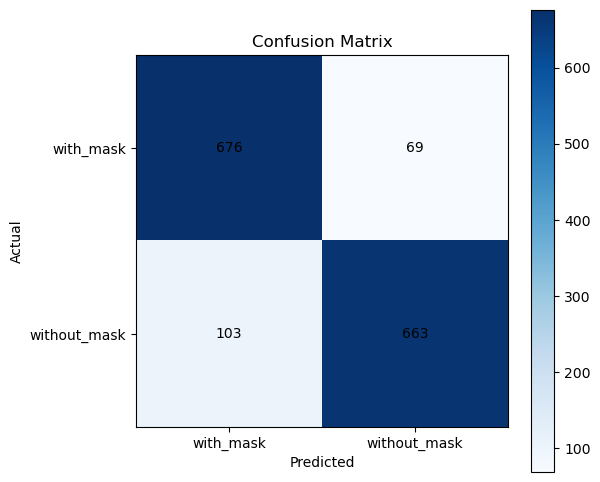

In [31]:
# =========================================================
# CELL 15 : VISUALIZATION
# =========================================================

plt.figure(figsize=(6,6))

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks([0,1], classes)

plt.yticks([0,1], classes)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i,j],
            ha='center',
            va='center'
        )

plt.colorbar()

plt.show()